# Notebook to determine head and tail from a skeleton that has Head and Tail outside the skeleton

Find distances between points with the math.hypth function:
    https://stackoverflow.com/questions/5228383/how-do-i-find-the-distance-between-two-points

In [7]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import os
from skimage.morphology import skeletonize

import cv2
import skan

In [ ]:
#which image
#this is a coiled shape dict for worm:
#2020-07-01_18-36-25_control_worm6-channel-
coiled_shapes_dict={'ot1.tif':np.arange(2800,5603),
                    'ot2.tif':np.arange(6676,7300),
                    'ot3.tif':np.arange(18500,21000),
                    'ot4.tif':np.arange(21600,22345),
                    'ot5.tif':np.arange(24300,24900),
                    'ot6.tif':np.arange(27616,28200),
                    'ot7.tif':np.arange(34588,35400),
                    'ot8.tif':np.arange(38980,40000),
                    'ot9.tif':np.arange(47800,48600),
                    'ot10.tif':np.arange(59300,60100),
                    'ot11.tif':np.arange(62150,63340),
                    'ot12.tif':np.arange(93780,94100),
                    'ot13.tif':np.arange(108150,109350),
                    'ot14.tif':np.arange(116500,117200),
                    'ot15.tif':np.arange(163100,163600),
                    'ot16.tif':np.arange(165660,166690),
                    'ot17.tif':np.arange(171200,172400),
                    'ot18.tif':np.arange(172900,173960),
                    'ot19.tif':np.arange(194195,195000)}

In [ ]:
#load hdf5 from DLC
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_777500_filtered.h5'
df=pd.read_hdf(path)
scorer=df.columns.get_level_values(0)[0]

In [ ]:
df.head(2)

In [ ]:
#read hdf5 file with the head coordinates
x_head, y_head =df[scorer]['Head']['x'].values,df[scorer]['Head']['y'].values
#tail coords
x_tail, y_tail =df[scorer]['Tail']['x'].values,df[scorer]['Tail']['y'].values



In [ ]:
fig, ax=plt.subplots(figsize=(15,10))
ax.plot(x_head,y_head)

In [ ]:
idx=1
x_head[idx]

In [ ]:
#img_path

img_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf'
tif=tiff.TiffFile(img_path)

img=tif.pages[idx].asarray()

skel=skeletonize(img/255)

labeled_img=img.copy()
#cv2.drawKeypoints(img,, labeled_img,)
labeled_img=cv2.circle(labeled_img, (int(x_head[idx]), int(y_head[idx])), 10, (200,200,200), 2)
labeled_img=cv2.circle(labeled_img, (int(x_tail[idx]), int(y_tail[idx])), 10, (200,200,200), 2)



In [ ]:
#get skeleton tips coordinates (could they be more than 2?, i am afraid so)
#using skan package? or manually input for the time being
from skan import skeleton_to_csgraph


pixel_graph, coordinates, degrees = skeleton_to_csgraph(skel)

#tiff.imwrite('degrees.tiff', degrees.astype(np.uint8))

In [ ]:
#plotting
fig, axes =plt.subplots(figsize=(15,5), ncols=3, nrows=1,dpi=150)

axes[0].imshow(img)
axes[0].imshow(skel, alpha=.5)
axes[1].imshow(labeled_img)
axes[2].imshow(degrees)
    

In [ ]:
degrees

In [ ]:
plt.imshow(img[325:375,275:325])
plt.imshow(degrees[325:375,275:325], alpha=0.9)

In [ ]:
plt.imshow(img[230:285,245:305])
plt.imshow(degrees[230:285,245:305], alpha=0.9)
plt.imshow(labeled_img[230:285,245:305], alpha=0.9)

In [ ]:
coords=np.where(degrees==1)
coords

In [ ]:
list(zip(*coords))

In [ ]:
#gets the edge coordinates and puts them on a list of tuples
edge_coords=list(zip(*np.where(degrees==1)))
print(edge_coords)

## Trying it with lists and numpy arrays

See below for the attempt with dataframes

In [ ]:
total_sum=[]
#loop through every ending/edge
for i, (x,y) in enumerate(edge_coords):
    #calculate the distance from that ending to the body part
    dist_head = math.hypot(x - x_head[idx], y - y_head[idx])
    dist_tail = math.hypot(x - x_tail[idx], y - y_tail[idx])
    print('x:', x, ' y:', y)
    print('distance from point ', i, 'to head ', dist_head)
    print('distance from point ', i, 'to tail ', dist_tail)
    total_sum.append(dist_head+dist_tail)

In [ ]:
#MAYBE it would be better to loop for every body part:
for i, bodypart in enumerate(bodyparts):
    dist=math.hypoth(bodypart[idx], point)

In [ ]:
#find the minimal cost combination

distances_head=[25,14,95]
distances_tail=[32,30,115]

In [ ]:
#test
# distances_head=list(np.arange(1,6,1))
# distances_tail=list(np.arange(1,6,1))

In [ ]:
distances_tail

In [ ]:
#Some sums are not valid because they correspond to one point being the closest to the two ends of the centerline
bad_ones=result_np[np.arange(0, len(result), len(distances_tail)+1)]
print(bad_ones)
bad_ones=np.arange(0, len(result), len(distances_tail)+1)
bad_ones

In [ ]:
#this is creating a list
import itertools

somelists = [
   distances_head,
   distances_tail]

#result list
result=[]

for x,y in itertools.product(*somelists):
    print(x+y)
    result.append(x+y)

In [ ]:
#convert the list into numpy array type float
result_np=np.array(result, dtype=float)

In [ ]:
result_np = result_np.astype(float)

In [ ]:
#Some sums are not valid because they correspond to one point being the closest to the two ends of the centerline
bad_ones=result_np[np.arange(0, len(result), len(distances_tail)+1)]
bad_ones

In [ ]:
#non valid indexes
invalid_indexes=np.arange(0, len(result), len(distances_tail)+1)

In [ ]:
result_np[invalid_indexes] = np.nan

In [ ]:
result_np

In [ ]:
#find the nanmin
np.nanmin(result_np)

In [ ]:
#find where the nanmin is
min_combination=np.where(result_np==np.nanmin(result_np))

In [ ]:
min_combination[0][0]

In [ ]:
somelists[min_combination[0][0]]

In [ ]:
result_np==np.nanmin(result_np)

In [ ]:
np.where(result_np[invalid_indexes], np.nan)

In [ ]:
result_np

In [ ]:
#calculate the min
min_sum=np.where(result_np==result_np.min())
min_sum

In [ ]:
calculate min in a for loop excluding the value for values on the invalid_indexes
for invalid_index in invalid_indexes:
    min_sum=np.where(result_np==result_np.min())
    if min_sum in invalid_indexes:
        

In [ ]:
#is the min sum one of the not valid indexes? then do something and search for another min
result_np[min_sum]

In [ ]:
#remove the combinations that arise from the same element of the list
x = np.delete(result, np.arange(0, len(result), len(distances_tail)+1))

# With dataframes
Now that I have solved the problem, I think it is better to do it with dataframes.

Now adding functions to run it better

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import tifffile as tiff

from skimage.morphology import skeletonize

import cv2

import itertools

from skan import skeleton_to_csgraph

import csv

import time

In [2]:
from head_and_tail import *

In [ ]:
#load hdf5 from DLC
path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_777500_filtered.h5'
df=pd.read_hdf(path)

In [ ]:
head_coords=load_bodypart_coords_from_DLC(df, 'Head')
tail_coords=load_bodypart_coords_from_DLC(df, 'Tail')

In [ ]:
idx=15

In [ ]:
#img_path
img_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf'
tif=tiff.TiffFile(img_path)

img=tif.pages[idx].asarray()

skel=skeletonize(img/255)

In [ ]:
pixel_graph, coordinates, degrees = skeleton_to_csgraph(skel)

In [ ]:
#my function to get the edge_coords
number_of_neighbours=1
edge_coords=get_skeleton_points(skel, number_of_neighbours)

In [ ]:
#prepare funcion
#assign head and tail coordinates to tuples
head_coords_i=(head_coords[1][idx],head_coords[0][idx])
tail_coords_i=(tail_coords[1][idx],tail_coords[0][idx])

In [ ]:
#run function
skel_head,skel_tail=assign_head_and_tail_to_coords(head_coords_i, tail_coords_i, candidate_coords=edge_coords)
skel_head, skel_tail

In [ ]:
#run wrapper
t = time.time()
print(t)
#load hdf5 from DLC
hdf5_dlc_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_777500_filtered.h5'
#img_path
img_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf'
#csv output filepath
csv_output_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_head_and_tail_from_unet/2020-07-01_18-36-25_control_worm6_skel.csv'

head_and_tail_wrapper(hdf5_dlc_path, img_path, csv_output_filepath)


elapsed = time.time() - t
print(elapsed)

1631114463.2547717


In [ ]:
csv_writer_path.close()

In [ ]:
new_df=pd.read_csv('skeleton_XY_coords.csv')#, header=None)

In [ ]:
new_df

## Plotting

In [ ]:
#label edge_coords
edges_img=img.copy()

for point in edge_coords:
    print(point)
    #points need to be inverted in the tuple because of matplotlib and array 0,0 coordinate are different
    edges_img=cv2.circle(edges_img, point[::-1], 10, (200,200,200), 2)

In [ ]:
head_coords_i

In [ ]:
int(head_coords_i)

In [ ]:
#label head and tail
labeled_img=img.copy()

labeled_img=cv2.circle(labeled_img, (int(head_coords_i[0]), int(head_coords_i[1])), 10, (200,200,200), 2)
labeled_img=cv2.circle(labeled_img, (int(tail_coords_i[0]), int(tail_coords_i[1])), 10, (200,200,200), 2)

In [ ]:
#plotting
fig, axes =plt.subplots(figsize=(15,5), ncols=3, nrows=1,dpi=300)

axes[0].imshow(img)
axes[0].imshow(skel, alpha=.5)
axes[1].imshow(labeled_img)
axes[2].imshow(degrees)
axes[2].imshow(edges_img, alpha=.5)

In [ ]:
#plotting
fig, axes =plt.subplots(figsize=(15,5), ncols=3, nrows=1,dpi=150)

axes[0].imshow(img)
axes[0].imshow(skel, alpha=.5)
axes[1].imshow(labeled_img)
axes[2].imshow(degrees[220:300,250:300])
axes[2].imshow(edges_img[220:300,250:300], alpha=.5)

In [16]:
# Testing skeleton
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import re

import skimage.graph
from skimage.morphology import skeletonize

import cv2
import skan

In [10]:
#inputs
#img
input_filename="/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_new_unet/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff_binary_200th.btf"

csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_head_and_tail_from_unet_test/2020-07-01_18-36-25_control_worm6_skel_cluster_objects.csv'

min_worm_len=300

In [12]:



df = pd.read_csv(csv_path)

head_coords_x=df['head coords x'].values
head_coords_y=df['head coords x'].values
tail_coords_x=df['tail coords x'].values
tail_coords_y=df['tail coords y'].values


# #create csv objects
output_path=os.path.join('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeleton_after_head_and_tail_from_unet_test/',re.split('-channel',re.split('/',input_filename)[-1])[0])

with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        img=page.asarray()
        
        start_point=(head_coords_x[i], head_coords_y[i])
        end_point=(tail_coords_x[i], tail_coords_y[i])
        if i==1: break

In [18]:
costs=skeletonize(img/255)

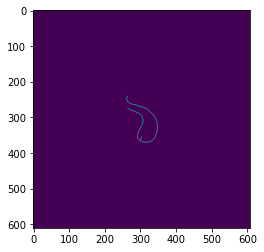

In [19]:
plt.imshow(costs)